In [1]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

conditions_EEG = {"MI": "Data_EEG_MI_DK_V2.mat", "Rest": "Data_EEG_Baseline_DK_V2.mat" }
conditions_MEG = {"MI": "Data_MEG_MI_DK_V2.mat", "Rest": "Data_MEG_Baseline_DK_V2.mat" }


In [2]:
import numpy as np

def read_subject(file, refs, subject_index, verbose=True):
    data = []
    
    # 96 trials, I read each trial
    for i in range (96):
        temp_trial = np.array(file[refs[i][subject_index]]).T
        if temp_trial.shape == (68, 1750):
            data.append(temp_trial)
        else:
            if verbose: print(f"subject_{subject_index} trial_{i} has wrong shape ({temp_trial.shape})")

    data=np.array(data)
    return data

In [3]:
from mne.time_frequency import psd_array_welch

def extract_features(data_MI, data_Rest, sfreq, starttime, endtime,
                    min_freq_frature, max_freq_frature, nbest_regions, 
                    kargs_welch={"fmin":2, "fmax":45,"n_per_seg":250, "n_fft":300,"n_overlap":125},
                    important_regions=[4, 5, 32, 33, 44, 45, 48, 49]):
    """
    Extract frequency-domain features from MI and Rest data.
    Features are the mean and max in a fixed window of freqs (min_freq_frature, max_freq_frature)
    For the nbest_regions ROIs (where i make sure to include the important regions).
    These are the regions where the max(Rest-MI) / max(Rest) has the max values.
    
    ----------
    - data_MI, data_Rest: (n_trials x n_ROIs x n_samples).
    - sfreq: sampling frequency
    - starttime, endtime : in secs, Segment boundaries to apply to data.
    - min_freq_frature, max_freq_frature:
        Frequency limits for feature extraction (where to compute mean and max)
    - nbest_regions : Number of most informative regions to select.
    - kargs_welch : dict, Parameters for scipy.signal.welch()
        kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
                "n_per_seg":n_per_seg, "n_fft":n_fft,
                "n_overlap":n_overlap}
    - important regions: Regions to be included for sure
    

    Returns
    -------
    - features_MI, - features_Rest: mean and max of each selected ROI, 
        computed in the freq interval (min_freq_frature,max_freq_frature)
    - labels_MI, - labels_Rest (0 for Rest and 1 for MI)
    - selected_regions
    """

    ntotROIs = data_MI.shape[1]
    nTrials_MI = data_MI.shape[0]
    nTrials_Rest = data_Rest.shape[0]
    #data.shape (trials, ROIs, timepoints)

    stime = 1 * starttime
    etime = 1 * endtime
    kargs_welch["sfreq"]=sfreq

    wpsdMI, frequiMI = psd_array_welch(data_MI[:,:,stime:-etime], **kargs_welch )
    wpsdRest, frequiRest = psd_array_welch(data_Rest[:,:,stime:-etime], **kargs_welch)
    # wpsdMI.shape (trials, ROIs, freqs)

    # search the best regions 
    # (regions where the the %difference at the freq with max difference is the highest)
    # I choose the nregions where I have the greatest difference between MI and Rest 
    # (but being careful to include the Interesting_regions)
    max_diff_perc = []
    max_rest = []
    for roi in range(ntotROIs):
        wpsdMI_1ROI =wpsdMI[:,roi,:]
        wpsdRest_1ROI =wpsdRest[:,roi,:]
        wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)
        wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)
        
        max_rest.append(np.max(wpsd_Rest_mean))
        max_diff_perc.append(np.max(wpsd_Rest_mean-wpsd_MI_mean)/max_rest[-1])
        

    selected_regions = [i for i in important_regions]
    for i in range(ntotROIs):
        if len(selected_regions) >= nbest_regions:
            break
        if np.argsort(max_diff_perc)[-i-1] not in selected_regions:
            selected_regions.append(int(np.argsort(max_diff_perc)[-i-1]))
        

    # selecting the freq range on wich compute features 
    # as features i chose the max and the maen of selected_ROIs 
    # in freqs (min_freq_frature, min_freq_frature)
    start_freq_idx = np.where(frequiMI>=min_freq_frature)[0][0]
    end_freq_idx = np.where(frequiMI<=max_freq_frature)[0][-1]

    wpsdRest_ROIs_freqs = wpsdRest[:,selected_regions,start_freq_idx:end_freq_idx]
    wpsdMI_ROIs_freqs = wpsdMI[:,selected_regions,start_freq_idx:end_freq_idx]
    # wpsdMI_ROIs_freqs.shape (trials, selected_ROIs, selected_Freqs)

    features_MI = np.concatenate((wpsdMI_ROIs_freqs.mean(axis=-1,keepdims=True),
                                wpsdMI_ROIs_freqs.max(axis=-1,keepdims=True)),
                                axis=-1)
    # features_MI.shape (Trials, selected_ROIs, 2)
    features_MI = features_MI.reshape(nTrials_MI,-1)

    features_Rest = np.concatenate((wpsdRest_ROIs_freqs.mean(axis=-1,keepdims=True),
                                wpsdRest_ROIs_freqs.max(axis=-1,keepdims=True)),
                                axis=-1)
    features_Rest = features_Rest.reshape(nTrials_Rest,-1)

    labels_MI = np.array([1 for i in range(nTrials_MI)])
    labels_Rest = np.array([0 for i in range(nTrials_Rest)])

    return features_MI, features_Rest, labels_MI, labels_Rest, selected_regions

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

def train_models(features, labels, n_kfold=5, scaler=StandardScaler, 
                 method=LinearDiscriminantAnalysis, seed=647):
    
    kf = KFold(n_splits=n_kfold, shuffle=True, random_state=seed)

    fold_accuracies = []
    fold_confusions = []
    trained_models = []
    val_indexes = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(features)):
        print(f"\n----- Fold {fold_idx+1} -----")

        X_train, X_val = features[train_idx], features[val_idx]
        y_train, y_val = labels[train_idx], labels[val_idx]
        val_indexes.append(val_idx)

        # StandardScaler:
        scaler_instance = scaler()
        X_train_scaled = scaler_instance.fit_transform(X_train)
        X_val_scaled   = scaler_instance.transform(X_val)

        # Model instance
        model = method()
        model.fit(X_train_scaled, y_train)
        trained_models.append(model)

        # Predict on validation
        y_pred = model.predict(X_val_scaled)

        # Accuracy
        acc = accuracy_score(y_val, y_pred)
        fold_accuracies.append(acc)

        # Confusion matrix
        cm = confusion_matrix(y_val, y_pred)
        fold_confusions.append(cm)

        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
        print(cm)

    # Summary
    print("\n==================================")
    print("Mean accuracy:", np.mean(fold_accuracies))
    print("Std accuracy:", np.std(fold_accuracies))
    return trained_models,val_indexes


In [ ]:
# Plot Atlas regionsfrom mne.viz import Brain
from mne.viz import Brain
import mne
import numpy as np
mne.viz.set_3d_backend('pyvistaqt')  # or 'pyvistaqt'
def plot_brain(regions_to_color=[], atlas="aparc", printnameregions=False, brain_object_dict={}, showbrainplot=True, savepath=None, colors=[(1, 0, 0)]):

    labels = mne.read_labels_from_annot("fsaverage", parc=atlas) # the Desikan-Killiany Atlas
    rtc = [i for i in regions_to_color]
    for i in range(len(rtc)):
        if type(rtc[i]) == int:
            rtc[i] = labels[rtc[i]].name
            if printnameregions:
                print(rtc[i])
    
    standard_dict = {
            "subject": "fsaverage",
            "surf": "pial",
            "hemi": "split", #split, both, lh,rh
            "background": "white",
            "views": ["dorsal"],
            "size": (600, 600),
            # Other parameters
            # "subjects_dir": subjects_dir,
            # "views": ["lat", "med"],
            # "offset": "auto",
            # "view_layout": "horizontal",
        }
        # 'dorsal', 'ventral', 'lat', 'medial', etc.)
        # views = 'medial'  # For example, 'lat' (lateral) view
        # brain.show_view(view=views)

    for key in standard_dict.keys():
        if key not in brain_object_dict:
            brain_object_dict[key] = standard_dict[key]
    brain_object_dict["show"] = showbrainplot

    brain = Brain(**brain_object_dict)

    if len(colors)==1:
        colors = np.repeat(colors, len(rtc), axis=0)
    elif len(colors)!= len(rtc):
        raise ValueError(f"Number of colors ({len(colors)}) must match number of regions_to_color ({len(rtc)}).")


    for i,region in enumerate(rtc):
        for label in labels:
            if label.name == region:
                brain.add_label(label, color=colors[i])  # Set color to red





    if savepath is not None:
        brain.save_image(savepath)

Using pyvistaqt 3d backend.


# Power spectra features - investigate EEG

In [ ]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

subject_index = 1
paat_MI = f"/Users/giovanni.messuti/Desktop/BCI_Project/Data/{conditions_EEG["MI"]}"
paat_Rest = f"/Users/giovanni.messuti/Desktop/BCI_Project/Data/{conditions_EEG["Rest"]}"

fMI = h5py.File(paat_MI, 'r')
refsMI = fMI[conditions_EEG["MI"][:-7]]

fRest = h5py.File(paat_Rest, 'r')
refsRest = fRest[conditions_EEG["Rest"][:-7]]

#Subjects_list = Subjects_dict[Subjects] # Other_subjects, Ok_subjects, Good_subjects
data_2_MI = read_subject(fMI, refsMI, subject_index)
data_2_Rest = read_subject(fRest, refsRest, subject_index)

# My frequency sampling
sfreq = 250

subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))
subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))


In [3]:
# power spectra with WELCH metod

#(fmin=0, fmax=inf, n_fft=256, 
# n_overlap, n_per_seg, n_fft,
#  window)

fmin=5
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

wpsdMI, frequiMI = psd_array_welch(data_2_MI[:,:,stime:-etime], **kargs )
wpsdRest, frequiRest = psd_array_welch(data_2_Rest[:,:,stime:-etime], **kargs )
wpsdRest.shape


NameError: name 'sfreq' is not defined

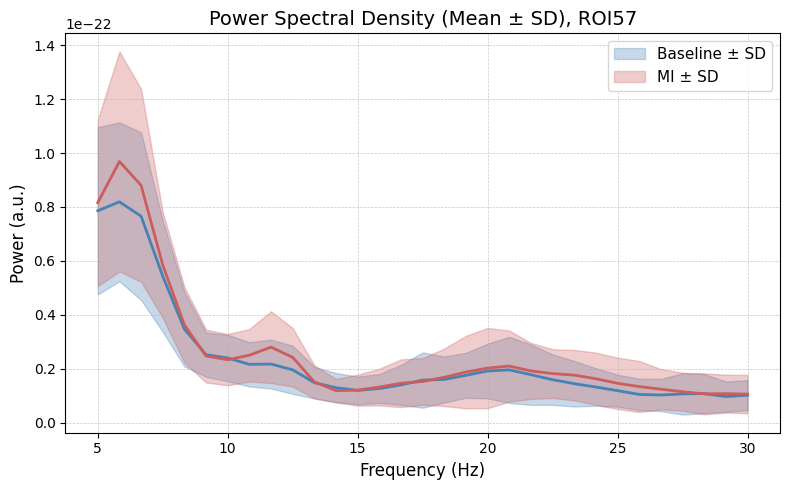

In [31]:
# some plot
ROI = 57
wpsdMI_1ROI =wpsdMI[:,ROI,:]
wpsdRest_1ROI =wpsdRest[:,ROI,:]

wpsd_MI_std = wpsdMI_1ROI.std(axis=0)
wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)

wpsd_Rest_std = wpsdRest_1ROI.std(axis=0)
wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)

plt.figure(figsize=(8, 5))

# --- Baseline condition ---
plt.fill_between(
    frequiRest, 
    wpsd_Rest_mean - wpsd_Rest_std, 
    wpsd_Rest_mean + wpsd_Rest_std,
    color="steelblue", alpha=0.3, label="Baseline ± SD"
)
plt.plot(frequiRest, wpsd_Rest_mean, color="steelblue", linewidth=2)

# --- MI condition ---
plt.fill_between(
    frequiMI, 
    wpsd_MI_mean - wpsd_MI_std, 
    wpsd_MI_mean + wpsd_MI_std,
    color="indianred", alpha=0.3, label="MI ± SD"
)
plt.plot(frequiMI, wpsd_MI_mean, color="indianred", linewidth=2)


plt.title(f"Power Spectral Density (Mean ± SD), ROI{ROI}", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Power (a.u.)", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [32]:
# selecting the ROIs where the difference between MI and Rest is max 

i_freq_max_rest=[] # indici delle frequenze di dove é il massimo
i_freq_max_diff=[] # .... where i find the max of diff
max_rest=[]
max_diff_perc=[] # max of the difference reported in percentage, not the maximum of the percentage difference

for roi in range(68):
    wpsdMI_1ROI =wpsdMI[:,roi,:]
    wpsdRest_1ROI =wpsdRest[:,roi,:]
    wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)
    wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)
    
    max_rest.append(np.max(wpsd_Rest_mean))
    # non lax rest, ma rest in quel bin
    max_diff_perc.append(np.max(wpsd_Rest_mean-wpsd_MI_mean)/max_rest[-1])

    i_freq_max_rest.append(np.argmax(wpsd_Rest_mean))
    i_freq_max_diff.append(np.argmax(wpsd_Rest_mean-wpsd_MI_mean))

i_freq_max_diff=np.array(i_freq_max_diff)
np.argsort(max_diff_perc) # from smaller to bigger

array([56, 57, 10,  5, 18, 29, 52,  3, 53, 54, 48, 55, 38, 36, 40,  2, 39,
       28, 64,  4, 60, 24, 25, 33, 11, 44, 49, 37, 63, 41, 65, 19, 31, 45,
       35, 46,  8, 16, 13, 14, 12,  9, 66,  0, 15, 22, 58, 47, 34, 23, 30,
        6, 27, 62, 20, 21, 50,  7, 32, 26,  1, 17, 51, 42, 59, 43, 61, 67])

In [33]:
# I choose the nregions where I have the greatest difference between MI and Rest 
# (but being careful to include the Interesting_regions)
nregions = 34 
selected_regions = [i for i in Interesting_regions]
for i in range(68):
    if np.argsort(max_diff_perc)[-i-1] not in selected_regions:
        selected_regions.append(int(np.argsort(max_diff_perc)[-i-1]))
    if len(selected_regions) >= nregions:
        break
    

array([10.        , 10.83333333, 11.66666667])

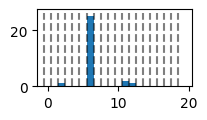

In [34]:
plt.figure(figsize=(2,1)) 
plt.hist(i_freq_max_diff[selected_regions],bins=np.array([i for i in range(20)])+0.5)
plt.vlines([i-0.5 for i in range(20)],*plt.ylim(), colors="black", linestyles="--", alpha=0.5)
frequiMI[[6,7,8]]
# the maximum difference for subject 2 is found at freqs with indexes 6,7,8

In [35]:
frequiMI

array([ 5.        ,  5.83333333,  6.66666667,  7.5       ,  8.33333333,
        9.16666667, 10.        , 10.83333333, 11.66666667, 12.5       ,
       13.33333333, 14.16666667, 15.        , 15.83333333, 16.66666667,
       17.5       , 18.33333333, 19.16666667, 20.        , 20.83333333,
       21.66666667, 22.5       , 23.33333333, 24.16666667, 25.        ,
       25.83333333, 26.66666667, 27.5       , 28.33333333, 29.16666667,
       30.        ])

In [36]:
min_freq_frature = 8
max_freq_feature = 14
start_freq_idx = np.where(frequiMI>=min_freq_frature)[0][0]
end_freq_idx = np.where(frequiMI<=max_freq_feature)[0][-1]

In [37]:
wpsdRest_ROIs_freqs = wpsdRest[:,selected_regions,start_freq_idx:end_freq_idx]
wpsdMI_ROIs_freqs = wpsdMI[:,selected_regions,start_freq_idx:end_freq_idx]
wpsdRest_ROIs_freqs.shape

(94, 34, 6)

In [40]:
# as features i chose the max and the maen of selected_ROIs in freqs 8.3 to 13.3
features_MI = np.concatenate((wpsdMI_ROIs_freqs.mean(axis=-1,keepdims=True),
                              wpsdMI_ROIs_freqs.max(axis=-1,keepdims=True)),
                              axis=-1)
print(features_MI.shape)
features_MI = features_MI.reshape(94,-1)

features_Rest = np.concatenate((wpsdRest_ROIs_freqs.mean(axis=-1,keepdims=True),
                              wpsdRest_ROIs_freqs.max(axis=-1,keepdims=True)),
                              axis=-1)
features_Rest = features_Rest.reshape(94,-1)

features_MI.reshape(94,-1).shape
# for each trial i have mean and max of each ROI: 2 features for each of the 34 ROI:
# for each trial i have 68 features (both for Rest and MI tasks)

(94, 34, 2)


(94, 68)

In [41]:
features = np.concatenate((features_Rest,features_MI),axis=0)
labels = np.array([0 for i in range (94)] + [1 for i in range (94)]) # 0 for Rest, 1 for MI
features.shape


(188, 68)

In [42]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

kf = KFold(n_splits=5, shuffle=True, random_state=264)

fold_accuracies = []
fold_confusions = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(features)):
    print(f"\n----- Fold {fold_idx+1} -----")

    X_train, X_val = features[train_idx], features[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]

    # StandardScaler:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)

    # LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)

    # Predict on validation
    y_pred = lda.predict(X_val_scaled)

    # Accuracy
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies.append(acc)

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_confusions.append(cm)

    print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
    print(cm)

# Summary
print("==================================")
print("Mean accuracy:", np.mean(fold_accuracies))
print("Std accuracy:", np.std(fold_accuracies))




----- Fold 1 -----
Fold 1 accuracy: 0.6579, Confusion matrix:
[[14  6]
 [ 7 11]]

----- Fold 2 -----
Fold 2 accuracy: 0.4737, Confusion matrix:
[[ 6  7]
 [13 12]]

----- Fold 3 -----
Fold 3 accuracy: 0.6053, Confusion matrix:
[[13  9]
 [ 6 10]]

----- Fold 4 -----
Fold 4 accuracy: 0.4865, Confusion matrix:
[[10  7]
 [12  8]]

----- Fold 5 -----
Fold 5 accuracy: 0.7027, Confusion matrix:
[[12 10]
 [ 1 14]]
Mean accuracy: 0.5852062588904694
Std accuracy: 0.09129520148172625


In [56]:
from sklearn.svm import SVC 

train_models(features,labels, method=SVC, seed=679)


----- Fold 1 -----
Fold 1 accuracy: 0.7368, Confusion matrix:
[[13 10]
 [ 0 15]]

----- Fold 2 -----
Fold 2 accuracy: 0.5000, Confusion matrix:
[[10 13]
 [ 6  9]]

----- Fold 3 -----
Fold 3 accuracy: 0.6842, Confusion matrix:
[[11  4]
 [ 8 15]]

----- Fold 4 -----
Fold 4 accuracy: 0.7297, Confusion matrix:
[[13  2]
 [ 8 14]]

----- Fold 5 -----
Fold 5 accuracy: 0.7568, Confusion matrix:
[[13  5]
 [ 4 15]]

Mean accuracy: 0.6815078236130867
Std accuracy: 0.09381048078884455


([SVC(), SVC(), SVC(), SVC(), SVC()],
 [array([  2,   6,   8,  16,  18,  20,  25,  28,  42,  43,  47,  49,  51,
          53,  58,  62,  64,  73,  79,  82,  88,  89,  91, 103, 113, 117,
         119, 120, 127, 131, 135, 137, 142, 147, 152, 165, 167, 182]),
  array([  3,   9,  15,  21,  22,  24,  33,  35,  38,  50,  52,  54,  55,
          59,  60,  61,  63,  69,  71,  72,  74,  75,  78,  96,  98, 106,
         110, 122, 125, 129, 139, 149, 168, 172, 175, 180, 181, 185]),
  array([  1,  11,  14,  17,  19,  29,  40,  44,  45,  48,  56,  68,  84,
          87,  90,  97, 100, 102, 108, 111, 114, 124, 132, 138, 140, 141,
         146, 151, 155, 156, 159, 161, 162, 170, 173, 177, 178, 183]),
  array([  5,  10,  13,  26,  27,  30,  31,  36,  41,  57,  67,  76,  83,
          85,  92, 104, 105, 109, 112, 115, 118, 123, 126, 128, 143, 144,
         145, 150, 154, 158, 163, 164, 169, 171, 176, 179, 186]),
  array([  0,   4,   7,  12,  23,  32,  34,  37,  39,  46,  65,  66,  70,
          77,  80

# Power spectra features - investigate MEG

In [ ]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

subject_index=1
paat_MI_MEG = f"/Users/giovanni.messuti/Desktop/BCI_Project/Data/{conditions_MEG["MI"]}"
paat_Rest_MEG = f"/Users/giovanni.messuti/Desktop/BCI_Project/Data/{conditions_MEG["Rest"]}"

fMI_MEG = h5py.File(paat_MI_MEG, 'r')
refsMI_MEG = fMI_MEG[conditions_MEG["MI"][:-7]]

fRest_MEG = h5py.File(paat_Rest_MEG, 'r')
refsRest_MEG = fRest_MEG[conditions_MEG["Rest"][:-7]]

#Subjects_list = Subjects_dict[Subjects] # Other_subjects, Ok_subjects, Good_subjects
data_2_MI_MEG = read_subject(fMI_MEG, refsMI_MEG, subject_index)
data_2_Rest_MEG = read_subject(fRest_MEG, refsRest_MEG, subject_index)

# My frequency sampling
sfreq = 250

subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))
subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))


In [46]:
# power spectra with WELCH metod

#(fmin=0, fmax=inf, n_fft=256, 
# n_overlap, n_per_seg, n_fft,
#  window)

fmin=5
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

wpsdMI_MEG, frequiMI_MEG = psd_array_welch(data_2_MI_MEG[:,:,stime:-etime], **kargs )
wpsdRest_MEG, frequiRest_MEG = psd_array_welch(data_2_Rest_MEG[:,:,stime:-etime], **kargs )
wpsdRest_MEG.shape


Effective window size : 1.200 (s)
Effective window size : 1.200 (s)


(94, 68, 31)

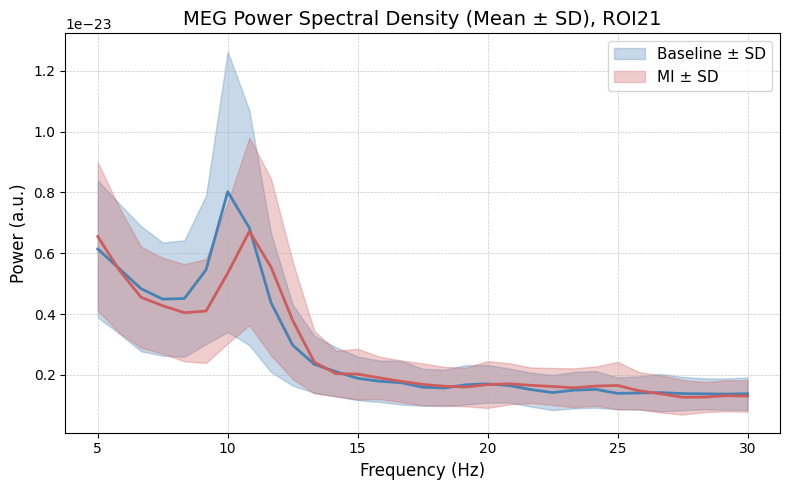

In [47]:
# some plot
ROI = 21
wpsdMI_1ROI_MEG =wpsdMI_MEG[:,ROI,:]
wpsdRest_1ROI_MEG =wpsdRest_MEG[:,ROI,:]

wpsd_MI_std_MEG = wpsdMI_1ROI_MEG.std(axis=0)
wpsd_MI_mean_MEG = wpsdMI_1ROI_MEG.mean(axis=0)

wpsd_Rest_std_MEG = wpsdRest_1ROI_MEG.std(axis=0)
wpsd_Rest_mean_MEG = wpsdRest_1ROI_MEG.mean(axis=0)

plt.figure(figsize=(8, 5))

# --- Baseline condition ---
plt.fill_between(
    frequiRest_MEG, 
    wpsd_Rest_mean_MEG - wpsd_Rest_std_MEG, 
    wpsd_Rest_mean_MEG + wpsd_Rest_std_MEG,
    color="steelblue", alpha=0.3, label="Baseline ± SD"
)
plt.plot(frequiRest_MEG, wpsd_Rest_mean_MEG, color="steelblue", linewidth=2)

# --- MI condition ---
plt.fill_between(
    frequiMI_MEG, 
    wpsd_MI_mean_MEG- wpsd_MI_std_MEG, 
    wpsd_MI_mean_MEG + wpsd_MI_std_MEG,
    color="indianred", alpha=0.3, label="MI ± SD"
)
plt.plot(frequiMI_MEG, wpsd_MI_mean_MEG, color="indianred", linewidth=2)


plt.title(f"MEG Power Spectral Density (Mean ± SD), ROI{ROI}", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Power (a.u.)", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [48]:
# selecting the ROIs where the difference between MI and Rest is max 

i_freq_max_rest_MEG=[] # indici delle frequenze di dove é il massimo
i_freq_max_diff_MEG=[] # .... where i find the max of diff
max_rest_MEG=[]
max_diff_perc_MEG=[] # max of the difference reported in percentage, not the maximum of the percentage difference

for roi in range(68):
    wpsdMI_1ROI_MEG =wpsdMI_MEG[:,roi,:]
    wpsdRest_1ROI_MEG =wpsdRest_MEG[:,roi,:]
    wpsd_MI_mean_MEG = wpsdMI_1ROI_MEG.mean(axis=0)
    wpsd_Rest_mean_MEG = wpsdRest_1ROI_MEG.mean(axis=0)
    
    max_rest_MEG.append(np.max(wpsd_Rest_mean_MEG))
    max_diff_perc_MEG.append(np.max(wpsd_Rest_mean_MEG-wpsd_MI_mean_MEG)/max_rest_MEG[-1])

    i_freq_max_rest_MEG.append(np.argmax(wpsd_Rest_mean_MEG))
    i_freq_max_diff_MEG.append(np.argmax(wpsd_Rest_mean_MEG-wpsd_MI_mean_MEG))

i_freq_max_diff_MEG=np.array(i_freq_max_diff_MEG)
np.argsort(max_diff_perc_MEG) # from smaller to bigger

array([36, 10, 55, 38,  0, 57, 61, 65, 56, 11, 64, 24, 25, 28, 35, 53, 34,
       37,  5, 39, 49, 63, 45, 29, 17,  8, 52, 16, 41, 40,  1, 54, 31, 67,
       19,  4, 13, 60, 48, 30,  2,  9,  3, 33, 47, 15, 12, 27, 46, 58, 26,
       44, 42, 18, 66, 22, 43, 20, 62, 23, 21, 59, 32, 51, 50,  7, 14,  6])

In [49]:
# I choose the nregions where I have the greatest difference between MI and Rest 
# (but being careful to include the Interesting_regions)
nregions_MEG = 34 
selected_regions_MEG = [i for i in Interesting_regions]
for i in range(68):
    if np.argsort(max_diff_perc_MEG)[-i-1] not in selected_regions_MEG:
        selected_regions_MEG.append(int(np.argsort(max_diff_perc_MEG)[-i-1]))
    if len(selected_regions_MEG) >= nregions_MEG:
        break
    

array([10.        , 10.83333333, 11.66666667])

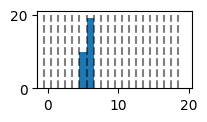

In [50]:
plt.figure(figsize=(2,1)) 
plt.hist(i_freq_max_diff_MEG[selected_regions_MEG],bins=np.array([i for i in range(20)])+0.5)
plt.vlines([i-0.5 for i in range(20)],*plt.ylim(), colors="black", linestyles="--", alpha=0.5)
frequiMI_MEG[[6,7,8]]
# the maximum differencefor subject 2 is found at freqs with indexes 6,7,8

In [14]:
frequiMI_MEG

array([ 5.        ,  5.83333333,  6.66666667,  7.5       ,  8.33333333,
        9.16666667, 10.        , 10.83333333, 11.66666667, 12.5       ,
       13.33333333, 14.16666667, 15.        , 15.83333333, 16.66666667,
       17.5       , 18.33333333, 19.16666667, 20.        , 20.83333333,
       21.66666667, 22.5       , 23.33333333, 24.16666667, 25.        ,
       25.83333333, 26.66666667, 27.5       , 28.33333333, 29.16666667,
       30.        ])

In [51]:
min_freq_frature_MEG = 8
max_freq_feature_MEG = 14
start_freq_idx_MEG = np.where(frequiMI_MEG>=min_freq_frature_MEG)[0][0]
end_freq_idx_MEG = np.where(frequiMI_MEG<=max_freq_feature_MEG)[0][-1]

In [52]:
wpsdRest_ROIs_freqs_MEG = wpsdRest_MEG[:,selected_regions_MEG,start_freq_idx_MEG:end_freq_idx_MEG]
wpsdMI_ROIs_freqs_MEG = wpsdMI_MEG[:,selected_regions_MEG,start_freq_idx_MEG:end_freq_idx_MEG]
wpsdRest_ROIs_freqs_MEG.shape

(94, 34, 6)

In [53]:
# as features i chose the max and the maen of selected_ROIs in freqs 8.3 to 13.3
features_MI_MEG = np.concatenate((wpsdMI_ROIs_freqs_MEG.mean(axis=-1,keepdims=True),
                              wpsdMI_ROIs_freqs_MEG.max(axis=-1,keepdims=True)),
                              axis=-1)
print(features_MI_MEG.shape)
features_MI_MEG = features_MI_MEG.reshape(94,-1)

features_Rest_MEG = np.concatenate((wpsdRest_ROIs_freqs_MEG.mean(axis=-1,keepdims=True),
                              wpsdRest_ROIs_freqs_MEG.max(axis=-1,keepdims=True)),
                              axis=-1)
features_Rest_MEG = features_Rest_MEG.reshape(94,-1)

features_MI_MEG.reshape(94,-1).shape
# for each trial i have mean and max of each ROI: 2 features for each of the 34 ROI:
# for each trial i have 68 features (both for Rest and MI tasks)

(94, 34, 2)


(94, 68)

In [54]:
features_MEG = np.concatenate((features_Rest_MEG,features_MI_MEG),axis=0)
labels_MEG = np.array([0 for i in range (96)] + [1 for i in range (96)]) # 0 for Rest, 1 for MI
features_MEG.shape


(188, 68)

In [60]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

kf = KFold(n_splits=5, shuffle=True, random_state=264)

fold_accuracies = []
fold_confusions = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(features_MEG)):
    print(f"\n----- Fold {fold_idx+1} -----")

    X_train, X_val = features_MEG[train_idx], features_MEG[val_idx]
    y_train, y_val = labels_MEG[train_idx], labels_MEG[val_idx]

    # StandardScaler:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)

    # LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)

    # Predict on validation
    y_pred = lda.predict(X_val_scaled)

    # Accuracy
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies.append(acc)

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_confusions.append(cm)

    print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
    print(cm)

# Summary
print("==================================")
print("Mean accuracy:", np.mean(fold_accuracies))
print("Std accuracy:", np.std(fold_accuracies))




----- Fold 1 -----
Fold 1 accuracy: 0.6842, Confusion matrix:
[[16  4]
 [ 8 10]]

----- Fold 2 -----
Fold 2 accuracy: 0.6842, Confusion matrix:
[[ 9  5]
 [ 7 17]]

----- Fold 3 -----
Fold 3 accuracy: 0.7105, Confusion matrix:
[[15  7]
 [ 4 12]]

----- Fold 4 -----
Fold 4 accuracy: 0.7568, Confusion matrix:
[[12  5]
 [ 4 16]]

----- Fold 5 -----
Fold 5 accuracy: 0.7297, Confusion matrix:
[[17  6]
 [ 4 10]]
Mean accuracy: 0.7130867709815079
Std accuracy: 0.027778720907503034


In [59]:
from sklearn.svm import SVC 

train_models(features,labels, method=SVC, seed=267)


----- Fold 1 -----
Fold 1 accuracy: 0.6316, Confusion matrix:
[[14  8]
 [ 6 10]]

----- Fold 2 -----
Fold 2 accuracy: 0.6579, Confusion matrix:
[[ 9  8]
 [ 5 16]]

----- Fold 3 -----
Fold 3 accuracy: 0.7368, Confusion matrix:
[[18  5]
 [ 5 10]]

----- Fold 4 -----
Fold 4 accuracy: 0.7297, Confusion matrix:
[[12  5]
 [ 5 15]]

----- Fold 5 -----
Fold 5 accuracy: 0.7297, Confusion matrix:
[[10  5]
 [ 5 17]]

Mean accuracy: 0.6971550497866288
Std accuracy: 0.04367809359405058


([SVC(), SVC(), SVC(), SVC(), SVC()],
 [array([  7,  11,  16,  18,  26,  41,  49,  51,  60,  61,  62,  65,  72,
          74,  75,  76,  77,  81,  84,  86,  87,  93, 104, 105, 108, 111,
         117, 124, 133, 137, 146, 151, 165, 166, 167, 173, 181, 187]),
  array([  1,   3,   9,  19,  22,  23,  25,  27,  28,  36,  37,  38,  54,
          59,  69,  88,  89,  94,  96, 103, 106, 110, 113, 114, 116, 118,
         120, 123, 128, 129, 144, 150, 154, 156, 169, 172, 175, 176]),
  array([  5,   8,  14,  15,  20,  21,  29,  31,  35,  40,  44,  45,  55,
          56,  63,  64,  67,  70,  71,  80,  83,  85,  91,  99, 121, 131,
         134, 136, 138, 139, 140, 148, 153, 158, 164, 171, 178, 184]),
  array([  2,   4,   6,  10,  13,  24,  30,  32,  33,  34,  42,  43,  48,
          50,  68,  73,  78,  97,  98, 101, 102, 107, 112, 119, 125, 126,
         127, 141, 142, 155, 157, 160, 162, 170, 174, 177, 183]),
  array([  0,  12,  17,  39,  46,  47,  52,  53,  57,  58,  66,  79,  82,
          90,  92

# Integrate MEG EEG

In [ ]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt
subject_index=2

print(f"\n\n Subject {subject_index}")
paat_MI_MEG = f"/Users/giovanni.messuti/Desktop/BCI_Project/Data/{conditions_MEG["MI"]}"
paat_Rest_MEG = f"/Users/giovanni.messuti/Desktop/BCI_Project/Data/{conditions_MEG["Rest"]}"

paat_MI_EEG = f"/Users/giovanni.messuti/Desktop/BCI_Project/Data/{conditions_EEG["MI"]}"
paat_Rest_EEG = f"/Users/giovanni.messuti/Desktop/BCI_Project/Data/{conditions_EEG["Rest"]}"

fMI_MEG = h5py.File(paat_MI_MEG, 'r')
refsMI_MEG = fMI_MEG[conditions_MEG["MI"][:-7]]

fRest_MEG = h5py.File(paat_Rest_MEG, 'r')
refsRest_MEG = fRest_MEG[conditions_MEG["Rest"][:-7]]

fMI_EEG = h5py.File(paat_MI_EEG, 'r')
refsMI_EEG = fMI_EEG[conditions_EEG["MI"][:-7]]

fRest_EEG = h5py.File(paat_Rest_EEG, 'r')
refsRest_EEG = fRest_EEG[conditions_EEG["Rest"][:-7]]

#Subjects_list = Subjects_dict[Subjects] # Other_subjects, Ok_subjects, Good_subjects
data_2_MI_EEG = read_subject(fMI_EEG, refsMI_EEG, subject_index)
data_2_Rest_EEG = read_subject(fRest_EEG, refsRest_EEG, subject_index)

#Subjects_list = Subjects_dict[Subjects] # Other_subjects, Ok_subjects, Good_subjects
data_2_MI_MEG = read_subject(fMI_MEG, refsMI_MEG, subject_index)
data_2_Rest_MEG = read_subject(fRest_MEG, refsRest_MEG, subject_index)


# My frequency sampling
sfreq = 250



 Subject 2


In [11]:
fmin=5
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

miff = 8
maff = 14
nbs=30

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

#  return features_MI, features_Rest, labels_MI, labels_Rest, selected_regions
Feat_extraction_EEG = extract_features(data_2_MI_EEG, data_2_Rest_EEG, 
                                sfreq, starttime=stime, endtime=etime,
                                min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, selected_regions_EEG = Feat_extraction_EEG

Feat_extraction_MEG = extract_features(data_2_MI_MEG, data_2_Rest_MEG,
                                sfreq, starttime=stime, endtime=etime,
                                min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_MEG,Feat_Rest_MEG, labls_MI_MEG,labls_Rest_MEG, selected_regions_MEG = Feat_extraction_MEG

Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)


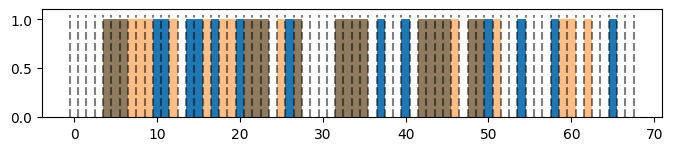

In [12]:
# see which regions have been chosen
plt.figure(figsize=(8,1.4)) 
a,b,c = plt.hist(selected_regions_EEG, bins=[i-0.5 for i in range(69)])
a,b,c = plt.hist(selected_regions_MEG, bins=[i-0.5 for i in range(69)],alpha=0.5)
plt.vlines([i-0.5 for i in range(69)],*plt.ylim(), colors="black", linestyles="--", alpha=0.5)

In [13]:
all_selected_ROIs = [i for i in selected_regions_EEG if i not in selected_regions_MEG]
all_selected_ROIs = all_selected_ROIs + [i for i in selected_regions_MEG]
#all_selected_ROIs = [i for i in selected_regions_EEG if i in selected_regions_MEG]

Both_color = "orange"; EEG_color = "red"; MEG_color = "yellow"
colors = [
    Both_color if (i in selected_regions_MEG and i in selected_regions_EEG)
    else MEG_color if i in selected_regions_MEG
    else EEG_color
    for i in all_selected_ROIs
]
all_selected_ROIs

[14,
 26,
 10,
 11,
 20,
 58,
 50,
 37,
 54,
 15,
 40,
 17,
 65,
 4,
 5,
 32,
 33,
 44,
 45,
 48,
 49,
 7,
 43,
 62,
 51,
 23,
 35,
 6,
 59,
 42,
 16,
 9,
 34,
 27,
 19,
 46,
 8,
 12,
 60,
 22,
 25,
 21,
 18]

In [14]:
plot_brain(all_selected_ROIs, brain_object_dict={"title":"EEG","hemi": "both"}, colors=colors)

Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot


In [71]:
Features_MI = np.concatenate((Feat_MI_EEG,Feat_MI_EEG), axis=1)
Features_Rest = np.concatenate((Feat_Rest_EEG,Feat_Rest_EEG), axis=1)
Features = np.concatenate((Features_MI,Features_Rest),axis=0)
Labels = np.concatenate((labls_MI_EEG,labls_Rest_EEG))
Feat_MI_MEG.shape, Features_MI.shape, Features.shape, labls_MI_EEG.shape, Labels.shape

((94, 68), (94, 136), (188, 136), (94,), (188,))

In [73]:
from sklearn.svm import SVC 
train_models(Features, Labels, n_kfold=5, scaler=StandardScaler, 
            method=SVC, seed=(5695))


----- Fold 1 -----
Fold 1 accuracy: 0.6316, Confusion matrix:
[[10  7]
 [ 7 14]]

----- Fold 2 -----
Fold 2 accuracy: 0.7105, Confusion matrix:
[[13  5]
 [ 6 14]]

----- Fold 3 -----
Fold 3 accuracy: 0.6579, Confusion matrix:
[[11  8]
 [ 5 14]]

----- Fold 4 -----
Fold 4 accuracy: 0.5676, Confusion matrix:
[[13  8]
 [ 8  8]]

----- Fold 5 -----
Fold 5 accuracy: 0.6486, Confusion matrix:
[[13  6]
 [ 7 11]]

Mean accuracy: 0.6432432432432432
Std accuracy: 0.04611672193632379


([SVC(), SVC(), SVC(), SVC(), SVC()],
 [array([  3,  11,  15,  17,  25,  29,  31,  34,  39,  40,  44,  46,  52,
          53,  59,  63,  70,  79,  81,  82,  89,  95,  96,  97, 114, 118,
         119, 133, 137, 138, 140, 157, 159, 161, 164, 165, 178, 185]),
  array([  6,  14,  18,  19,  26,  27,  28,  33,  41,  42,  43,  48,  49,
          50,  57,  73,  76,  77,  87,  88,  94, 100, 104, 111, 116, 117,
         121, 127, 129, 130, 143, 147, 149, 150, 156, 172, 177, 183]),
  array([  7,  12,  13,  16,  23,  24,  30,  35,  37,  47,  54,  55,  61,
          64,  67,  69,  74,  83,  91,  99, 101, 108, 110, 113, 115, 125,
         131, 141, 144, 145, 146, 151, 152, 154, 162, 167, 173, 184]),
  array([  0,   1,   4,   8,  10,  21,  32,  36,  45,  60,  66,  71,  75,
          78,  80,  85, 102, 103, 109, 112, 120, 124, 126, 134, 136, 139,
         142, 148, 153, 155, 160, 166, 169, 170, 171, 181, 186]),
  array([  2,   5,   9,  20,  22,  38,  51,  56,  58,  62,  65,  68,  72,
          84,  86

In [ ]:
Features.shape, Labels.shape

((192, 136), (68,))

# Investigate freq max difference Rest MI for each subjects

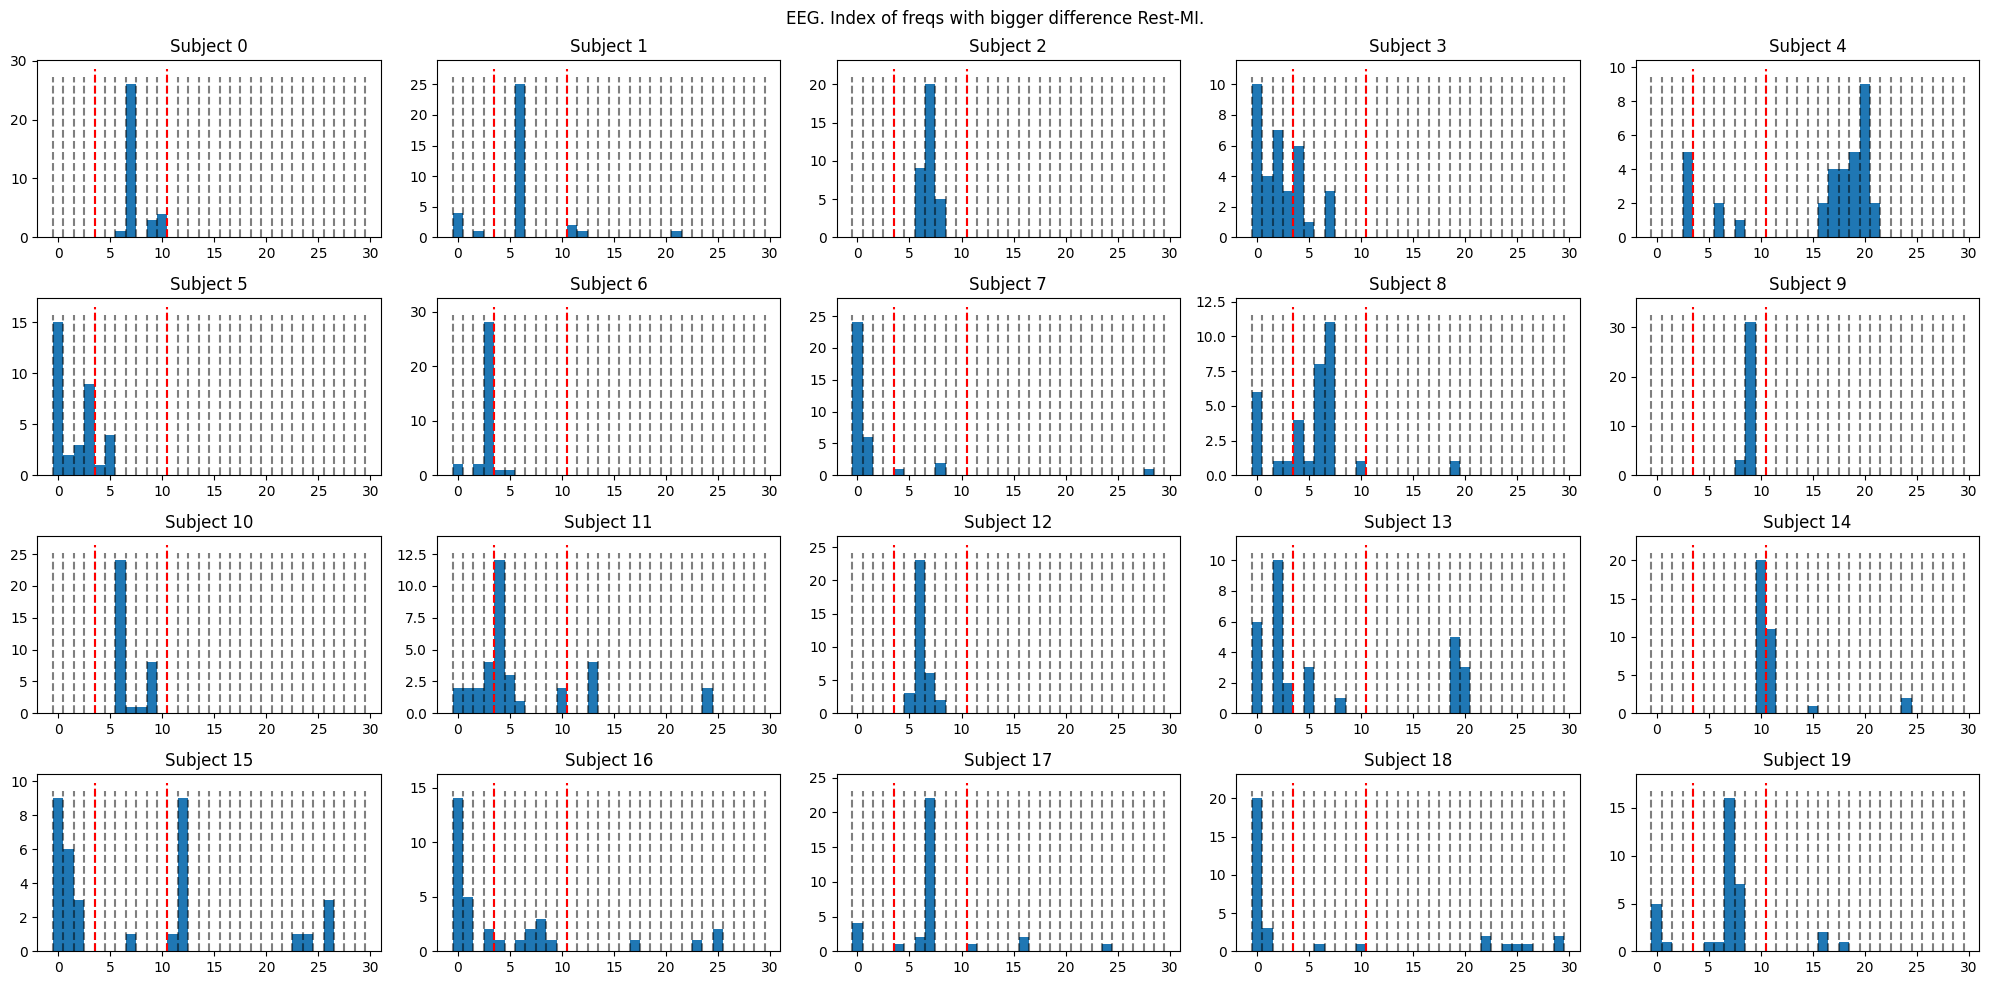

[ 8.33333333  9.16666667 10.         10.83333333 11.66666667 12.5
 13.33333333]


In [151]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

# My frequency sampling
sfreq = 250

# power spectra with WELCH metod

#(fmin=0, fmax=inf, n_fft=256, 
# n_overlap, n_per_seg, n_fft,
#  window)
nregions = 34 

fmin=5
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap, "verbose":False}

fig, axes = plt.subplots(4, 5, figsize=(20, 10))  
axes = axes.flatten()  

for subject_index in range(20):
    paat_MI = f"/Users/giovanni.messuti/Desktop/prova/Data/{conditions_EEG["MI"]}"
    paat_Rest = f"/Users/giovanni.messuti/Desktop/prova/Data/{conditions_EEG["Rest"]}"

    fMI = h5py.File(paat_MI, 'r')
    refsMI = fMI[conditions_EEG["MI"][:-7]]

    fRest = h5py.File(paat_Rest, 'r')
    refsRest = fRest[conditions_EEG["Rest"][:-7]]

    #Subjects_list = Subjects_dict[Subjects] # Other_subjects, Ok_subjects, Good_subjects
    data_2_MI = read_subject(fMI, refsMI, subject_index, verbose=False)
    data_2_Rest = read_subject(fRest, refsRest, subject_index, verbose=False)

    wpsdMI, frequiMI = psd_array_welch(data_2_MI[:,:,stime:-etime], **kargs )
    wpsdRest, frequiRest = psd_array_welch(data_2_Rest[:,:,stime:-etime], **kargs )
    wpsdRest.shape

    # selecting the ROIs where the difference between MI and Rest is max 

    i_freq_max_rest=[] # indici delle frequenze di dove é il massimo
    i_freq_max_diff=[] # .... where i find the max of diff
    max_rest=[]
    max_diff_perc=[] # max of the difference reported in percentage, not the maximum of the percentage difference

    for roi in range(68):
        wpsdMI_1ROI =wpsdMI[:,roi,:]
        wpsdRest_1ROI =wpsdRest[:,roi,:]
        wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)
        wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)
        
        max_rest.append(np.max(wpsd_Rest_mean))
        max_diff_perc.append(np.max(wpsd_Rest_mean-wpsd_MI_mean)/max_rest[-1])

        i_freq_max_rest.append(np.argmax(wpsd_Rest_mean))
        i_freq_max_diff.append(np.argmax(wpsd_Rest_mean-wpsd_MI_mean))

    i_freq_max_diff=np.array(i_freq_max_diff)
    np.argsort(max_diff_perc) # from smaller to bigger
    # I choose the nregions where I have the greatest difference between MI and Rest 
    # (but being careful to include the Interesting_regions)
    
    selected_regions = [i for i in Interesting_regions]
    for i in range(68):
        if np.argsort(max_diff_perc)[-i-1] not in selected_regions:
            selected_regions.append(int(np.argsort(max_diff_perc)[-i-1]))
        if len(selected_regions) >= nregions:
            break
 
    ax = axes[subject_index]  # select the subplot for this subject
    ax.hist(i_freq_max_diff[selected_regions], bins=np.arange(31)-0.5)
    ax.vlines([i-0.5 for i in range(31)], *ax.get_ylim(), colors="black", linestyles="--", alpha=0.5)
    ax.vlines([3.5, 10.5], *ax.get_ylim(), colors="red", linestyles="--")
    ax.set_title(f"Subject {subject_index}")
plt.suptitle("EEG. Index of freqs with bigger difference Rest-MI.")
plt.tight_layout()
plt.show()

print(frequiMI[[4,5,6,7,8,9,10]])

In [ ]:
print(frequiMI)

[ 5.          5.83333333  6.66666667  7.5         8.33333333  9.16666667
 10.         10.83333333 11.66666667 12.5        13.33333333 14.16666667
 15.         15.83333333 16.66666667 17.5        18.33333333 19.16666667
 20.         20.83333333 21.66666667 22.5        23.33333333 24.16666667
 25.         25.83333333 26.66666667 27.5        28.33333333 29.16666667
 30.        ]


# TODO

To do:
- identificare quali sono le regioni (sui brainplot o solo labels se non riesco o almeno a qule lobo) selezionate
- T test - come scelta features (dove differenza è significativa)
- Performance vs Subject (EEG vs MEG vs EEG+MEG) vs REgioni selezionate
- Salva in dataframe, 
- Traccia i soggetti nel grafico finale
- Fai classificazione con tutte le regioni; a posteriori di SVM controlla quali sono le più significative (T test su differenza tra MI e Rest)
